Ενεργή συσκευή εκπαίδευσης: cuda
--- Ενεργά Στοιχεία Ablation Study (EfficientNet-B0) ---
Weighted Loss: True | Basic Augm: True | CutMix: False | Scheduler: False
Epoch 01/15 -> Train Loss: 1.4030 Acc: 0.5736 | Test Loss: 1.0214 Acc: 0.6231 | LR: 0.000100
Epoch 02/15 -> Train Loss: 0.7830 Acc: 0.7036 | Test Loss: 0.8157 Acc: 0.6860 | LR: 0.000100
Epoch 03/15 -> Train Loss: 0.6043 Acc: 0.7493 | Test Loss: 0.6228 Acc: 0.7594 | LR: 0.000100
Epoch 04/15 -> Train Loss: 0.4788 Acc: 0.7827 | Test Loss: 0.5832 Acc: 0.7863 | LR: 0.000100
Epoch 05/15 -> Train Loss: 0.3853 Acc: 0.8083 | Test Loss: 0.6073 Acc: 0.7723 | LR: 0.000100
Epoch 06/15 -> Train Loss: 0.3454 Acc: 0.8214 | Test Loss: 0.5108 Acc: 0.8143 | LR: 0.000100
Epoch 07/15 -> Train Loss: 0.2941 Acc: 0.8432 | Test Loss: 0.5471 Acc: 0.8113 | LR: 0.000100
Epoch 08/15 -> Train Loss: 0.2461 Acc: 0.8668 | Test Loss: 0.5108 Acc: 0.8073 | LR: 0.000100
Epoch 09/15 -> Train Loss: 0.2409 Acc: 0.8674 | Test Loss: 0.5410 Acc: 0.8033 | LR: 0.000100

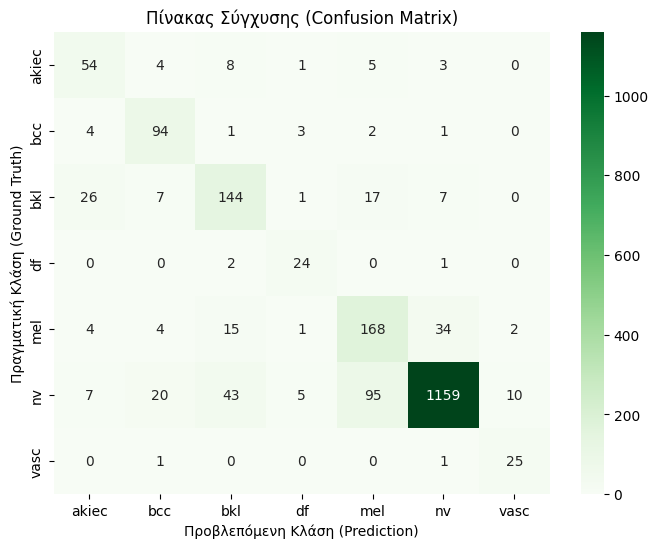

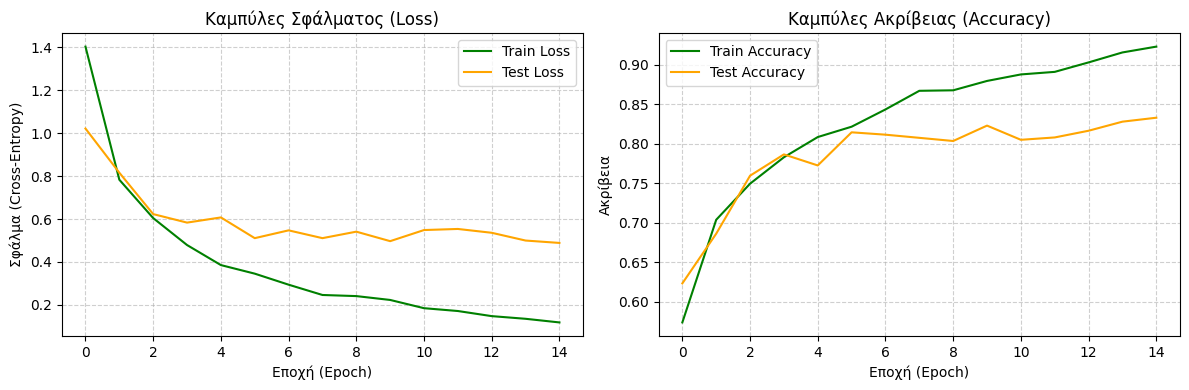

In [3]:
# ==============================================================================
# ΕΝΟΤΗΤΑ 1: ΕΙΣΑΓΩΓΗ ΒΙΒΛΙΟΘΗΚΩΝ ΚΑΙ ΡΥΘΜΙΣΗ ΠΕΡΙΒΑΛΛΟΝΤΟΣ
# ==============================================================================
import os # Βιβλιοθήκη για περιήγηση στους φακέλους του λειτουργικού συστήματος
import pandas as pd # Απαραίτητη για τη διαχείριση του αρχείου CSV (μεταδεδομένα του HAM10000)
import numpy as np # Μαθηματική βιβλιοθήκη για πράξεις γραμμικής άλγεβρας και διαχείριση πινάκων
import matplotlib.pyplot as plt # Βιβλιοθήκη οπτικοποίησης (για τη δημιουργία των τελικών διαγραμμάτων)
import seaborn as sns # Στατιστική οπτικοποίηση, "πάνω" από τη matplotlib, για όμορφα confusion matrices
from PIL import Image # Python Imaging Library για το άνοιγμα των φυσικών αρχείων εικόνας (.jpg)
import random # Ενσωματωμένη βιβλιοθήκη Python για διαχείριση τυχαιότητας
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score # Έτοιμες ιατρικές μετρικές (Precision, Recall, AUC)

import torch # Η καρδιά του Deep Learning κώδικά μας (PyTorch)
import torch.nn as nn # Απαραίτητο για τα Neural Network layers (π.χ. nn.Linear, nn.CrossEntropyLoss)
import torch.optim as optim # Περιέχει τους αλγορίθμους εκπαίδευσης/βελτιστοποίησης (π.χ. AdamW)
from torch.utils.data import Dataset, DataLoader, random_split, Subset # Εργαλεία για την οργάνωση των δεδομένων σε παρτίδες
from torchvision import transforms, models # Έτοιμες αρχιτεκτονικές μοντέλων και βασικοί μετασχηματισμοί
from torchvision.transforms import v2 # ΠΡΟΣΟΧΗ: Εισαγωγή της νεότερης έκδοσης (v2) που υποστηρίζει την τεχνική CutMix
import gdown # Εργαλείο κατεβάσματος αρχείων απευθείας από το Google Drive

# ==============================================================================
# ΕΞΑΣΦΑΛΙΣΗ ΑΝΑΠΑΡΑΓΩΓΙΜΟΤΗΤΑΣ (REPRODUCIBILITY)
# ==============================================================================
# Ο seed της τυχαιότητας. Το 42 είναι η καθιερωμένη τιμή στη βιβλιογραφία.
# Εξασφαλίζει ότι το split των δεδομένων (Train/Test) θα είναι απολύτως ίδιο σε όλα τα μοντέλα!
seed = 42
random.seed(seed) # Κλειδώνει τις τυχαίες λειτουργίες της βασικής Python (π.χ. shuffle λιστών)
np.random.seed(seed) # Κλειδώνει τις τυχαίες επιλογές πινάκων στο numpy
torch.manual_seed(seed) # Κλειδώνει τις γεννήτριες του PyTorch στον επεξεργαστή (CPU)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed) # Κλειδώνει την τυχαιότητα σε όλες τις διαθέσιμες κάρτες γραφικών
    torch.backends.cudnn.deterministic = True # Απαιτεί από την κάρτα γραφικών να κάνει σταθερούς υπολογισμούς
    torch.backends.cudnn.benchmark = False # Απενεργοποιεί τον δυναμικό εντοπισμό αλγορίθμων για να μην αλλάζει η απόδοση

# Έλεγχος συστήματος για κάρτα γραφικών. Αν υπάρχει, όλες οι πράξεις θα γίνονται ταχύτατα εκεί.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Ενεργή συσκευή εκπαίδευσης: {device}")

# ==============================================================================
# ΛΗΨΗ ΚΑΙ ΠΡΟΕΤΟΙΜΑΣΙΑ ΔΕΔΟΜΕΝΩΝ (HAM10000)
# ==============================================================================
# Συνδέσεις για τη λήψη του αρχείου μεταδεδομένων (CSV) και των εικόνων (ZIP)
CSV_LINK = 'https://drive.google.com/file/d/10dv3SgUizMjFy52VjI4j1vUS0vtn_HNp/view?usp=drive_link'
ZIP_LINK = 'https://drive.google.com/file/d/1lQ00H_BAI-r1wXSuf7Ib3vUH99j9s8v9/view?usp=drive_link'

# Λήψη των αρχείων στον χώρο εργασίας του Colab
gdown.download(CSV_LINK, 'HAM10000_metadata.csv', quiet=True, fuzzy=True)
gdown.download(ZIP_LINK, 'images.zip', quiet=True, fuzzy=True)

# Έλεγχος αν ο φάκελος εικόνων υπάρχει ήδη, ώστε να μην επαναλαμβάνεται η αποσυμπίεση
if not os.path.exists('HAM10000_images'):
    print("Αποσυμπίεση αρχείου εικόνων baseline...")
    !unzip -q images.zip -d HAM10000_images # Αθόρυβη αποσυμπίεση στο φάκελο HAM10000_images

# ==============================================================================
# ΕΝΟΤΗΤΑ 2: ΠΙΝΑΚΑΣ ΕΛΕΓΧΟΥ ΠΕΙΡΑΜΑΤΩΝ (ABLATION FLAGS)
# Αυτοί οι διακόπτες επιτρέπουν την επιστημονική αποδόμηση του μοντέλου (Ablation Study).
# Αλλάζοντας την τιμή σε False, η αντίστοιχη τεχνική απενεργοποιείται αυτόματα σε όλο τον κώδικα.
# ==============================================================================
USE_WEIGHTED_LOSS      = True  # Αντιμετωπίζει την ανισορροπία "τιμωρώντας" περισσότερο τα λάθη στις σπάνιες κλάσεις
USE_BASIC_AUGMENTATION = True  # Εφαρμόζει Color Jitter (αλλαγή φωτισμού) και Rotations (περιστροφές)
USE_CUTMIX             = False  # Εφαρμόζει την προηγμένη τεχνική CutMix για καλύτερη μίξη πληροφορίας
USE_SCHEDULER          = False  # Δυναμική μείωση του Learning Rate (βάσει συνημίτονου) προς το τέλος της εκπαίδευσης

print(f"--- Ενεργά Στοιχεία Ablation Study (EfficientNet-B0) ---")
print(f"Weighted Loss: {USE_WEIGHTED_LOSS} | Basic Augm: {USE_BASIC_AUGMENTATION} | CutMix: {USE_CUTMIX} | Scheduler: {USE_SCHEDULER}")

# ==============================================================================
# ΕΝΟΤΗΤΑ 3: ΔΥΝΑΜΙΚΟ DATA AUGMENTATION ΚΑΙ ΟΡΙΣΜΟΣ DATASET
# ==============================================================================
# Αν ο διακόπτης επαύξησης (Augmentation) είναι ενεργός, χρησιμοποιούμε πλούσιους μετασχηματισμούς
if USE_BASIC_AUGMENTATION:
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)), # Κλιμάκωση στην ανάλυση που περιμένει το EfficientNet-B0
        transforms.RandomHorizontalFlip(), # 50% πιθανότητα η εικόνα να γυρίσει οριζόντια (σαν καθρέφτης)
        transforms.RandomRotation(15), # Τυχαία περιστροφή της εικόνας από -15 έως +15 μοίρες
        # ColorJitter: Προσομοιώνει διαφορετικές συνθήκες φωτισμού στα δερματολογικά ιατρεία (±10%)
        transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
        transforms.ToTensor(), # Μετατροπή σε PyTorch Tensor
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Κανονικοποίηση (στάνταρ για ImageNet)
    ])
else:
    # Αν ο διακόπτης είναι False, κάνουμε μόνο τα απολύτως απαραίτητα (Resize & Normalize)
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

# ΚΡΙΣΙΜΟ: Το Test Set ΔΕΝ ΠΡΕΠΕΙ ΠΟΤΕ να δέχεται τυχαίους μετασχηματισμούς (Augmentation).
# Θέλουμε το μοντέλο να αξιολογηθεί στις πραγματικές, καθαρές εικόνες για να έχουμε αντικειμενικά νούμερα.
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Ενεργοποίηση της τεχνικής CutMix μέσω της νέας βιβλιοθήκης v2.
# Ορίζουμε num_classes=7 διότι στο HAM10000 έχουμε 7 διαφορετικές διαγνώσεις.
cutmix = v2.CutMix(num_classes=7) if USE_CUTMIX else None

class HAM10000Dataset(Dataset):
    """ Προσαρμοσμένη κλάση για να 'διαβάζει' το PyTorch τις εικόνες από τον σκληρό δίσκο. """
    def __init__(self, csv_file, img_dir, transform=None):
        self.df = pd.read_csv(csv_file) # Φόρτωση του πίνακα με τα ονόματα των εικόνων και τις διαγνώσεις
        self.transform = transform
        self.classes = sorted(self.df['dx'].unique().tolist()) # Αλφαβητική λίστα 7 κλάσεων (akiec, bcc, bkl, df, mel, nv, vasc)
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)} # Δημιουργία λεξικού κωδικοποίησης (π.χ. 'akiec' -> 0)

        # Έξυπνη αναζήτηση για να μη "σπάει" το path αν τα αρχεία μπουν σε υποφάκελο κατά το unzip
        sample_img = self.df.iloc[0]['image_id'] + '.jpg'
        for root, _, files in os.walk(img_dir):
            if sample_img in files:
                self.img_path = root # Αποθήκευση του σωστού φακέλου ρίζας
                break

    def __len__(self): return len(self.df) # Απαραίτητη συνάρτηση που επιστρέφει το 10.015 (Μέγεθος Dataset)

    def __getitem__(self, idx):
        # Αυτή η συνάρτηση καλείται από τον DataLoader για κάθε ξεχωριστή εικόνα
        img_name = os.path.join(self.img_path, self.df.iloc[idx]['image_id'] + '.jpg')
        image = Image.open(img_name).convert('RGB') # Φόρτωση σε RGB (αγνόηση πιθανών καναλιών διαφάνειας)
        label = self.class_to_idx[self.df.iloc[idx]['dx']] # Ανάκτηση του αριθμητικού label της ασθένειας (0-6)
        if self.transform: image = self.transform(image) # Πέρασμα από τα φίλτρα (Resize, Normalize)
        return image, label

# Φόρτωση ΔΥΟ ξεχωριστών αντιγράφων του συνόλου δεδομένων για αποφυγή επικάλυψης (Silent Bug Fix)
full_train_ds = HAM10000Dataset('HAM10000_metadata.csv', 'HAM10000_images', transform=train_transform)
full_test_ds  = HAM10000Dataset('HAM10000_metadata.csv', 'HAM10000_images', transform=test_transform)

# Μαθηματικός διαχωρισμός του Dataset σε Train (80%) και Test (20%).
# Το seed=42 που ορίσαμε στην αρχή εξασφαλίζει ότι το split αυτό θα είναι ίδιο σε ΟΛΑ τα μοντέλα!
dataset_size = len(full_train_ds)
train_size = int(0.8 * dataset_size)
test_size = dataset_size - train_size

# Δημιουργία τυχαίων δεικτών (indices) κλειδωμένων με το seed 42.
# Προσοχή: Δεν κόβουμε το ίδιο το dataset, αλλά μια λίστα με αριθμούς από 0 έως 10014.
train_indices, test_indices = random_split(range(dataset_size), [train_size, test_size])

# Δημιουργία των τελικών Subsets "κουμπώνοντας" τους δείκτες στα σωστά, ανεξάρτητα datasets
train_ds = Subset(full_train_ds, train_indices.indices)
test_ds  = Subset(full_test_ds, test_indices.indices)

# Δημιουργία των Loaders: Διαχειρίζονται τα batches (32 εικόνες/batch) και τη μεταφορά τους στη μνήμη της GPU.
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True) # Shuffle στο train για να μην αποστηθίζει σειρά το μοντέλο
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False) # Στον έλεγχο (test) η σειρά δεν έχει σημασία

# ==============================================================================
# ΕΝΟΤΗΤΑ 4: ΑΡΧΙΤΕΚΤΟΝΙΚΗ ΜΟΝΤΕΛΟΥ ΚΑΙ ΣΥΝΑΡΤΗΣΕΙΣ ΒΕΛΤΙΣΤΟΠΟΙΗΣΗΣ
# ==============================================================================
# Φορτώνουμε το EfficientNet-B0. Τα weights='DEFAULT' φέρνουν τα προεκπαιδευμένα βάρη του ImageNet (Transfer Learning)
model = models.efficientnet_b0(weights='DEFAULT')

# Προσαρμογή του μοντέλου στο πρόβλημά μας (7 ιατρικές κλάσεις αντί για 1000 γενικά αντικείμενα):
# Αλλάζουμε την "ουρά" (Linear επίπεδο στον Classifier) του δικτύου.
# Σημείωση: Το model.classifier[0] είναι το Dropout (στο 20%), το οποίο αφήνουμε άθικτο για προστασία από Overfitting.
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 7)
model = model.to(device) # Αποστολή των βαρών στη μνήμη της κάρτας γραφικών (ή CPU)

# Αντί για τον απλό Adam, χρησιμοποιούμε τον AdamW. Το "W" σημαίνει Weight Decay (αποσύζευξη).
# Αποτρέπει τα βάρη του δικτύου να μεγαλώσουν υπερβολικά, μειώνοντας δραστικά το overfitting.
optimizer = optim.AdamW(model.parameters(), lr=0.0001, weight_decay=0.01)

# Ενεργοποίηση του Scheduler: Θα μειώνει το Learning Rate σε σχήμα καμπύλης συνημιτόνου
# καταλήγοντας σχεδόν στο μηδέν στην 15η εποχή (T_max=15), για τέλειο "παρκάρισμα" στο ελάχιστο σφάλμα.
if USE_SCHEDULER:
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15)

# Δυναμική επιλογή της συνάρτησης σφάλματος (Loss Function) βάσει του Ablation Flag
if USE_WEIGHTED_LOSS:
    # Υπολογίζουμε πόσες φορές εμφανίζεται η κάθε κλάση (συχνότητα)
    counts = pd.read_csv('HAM10000_metadata.csv')['dx'].value_counts().sort_index().values
    # Το βάρος είναι αντιστρόφως ανάλογο της συχνότητας: Όσο λιγότερες οι εικόνες, τόσο μεγαλύτερο το βάρος.
    weights = 1.0 / torch.tensor(counts, dtype=torch.float)
    # Κανονικοποιούμε τα βάρη ώστε το άθροισμά τους να έχει λογική κλίμακα
    weights = (weights / weights.sum() * 7).to(device)
    # Περνάμε τον πίνακα με τα βάρη μέσα στη συνάρτηση σφάλματος
    criterion = nn.CrossEntropyLoss(weight=weights)
else:
    # Αν ο διακόπτης είναι False, χρησιμοποιούμε την απλή (άδικη για τις σπάνιες κλάσεις) συνάρτηση
    criterion = nn.CrossEntropyLoss()

# ==============================================================================
# ΕΝΟΤΗΤΑ 5: ΕΚΠΑΙΔΕΥΣΗ (TRAIN) & ΕΛΕΓΧΟΣ (TEST) ΜΕ ΔΥΝΑΜΙΚΗ ΕΝΣΩΜΑΤΩΣΗ ΤΕΧΝΙΚΩΝ
# ==============================================================================
# Αρχικοποίηση λεξικού για την καταγραφή της ιστορίας σφαλμάτων και ακρίβειας (για διαγράμματα)
history = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}

for epoch in range(15): # Θα περάσουμε όλα τα δεδομένα εκπαίδευσης 15 φορές (Εποχές)
    # --- ΦΑΣΗ ΕΚΠΑΙΔΕΥΣΗΣ ---
    model.train() # Ενημερώνει το δίκτυο ότι είμαστε σε εκπαίδευση (ανοίγει Dropout/Batch Normalization)
    t_loss, t_corr = 0, 0 # Μηδενισμός αθροιστών σφάλματος και σωστών προβλέψεων για την τρέχουσα εποχή

    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device) # Μεταφορά των 32 εικόνων του batch στην GPU
        optimizer.zero_grad() # Σημαντικό: Καθαρισμός των παραγώγων (gradients) από το προηγούμενο batch για να μην συσσωρεύονται

        # Αν η τεχνική CutMix είναι ενεργή, αναμειγνύουμε τα δεδομένα ΠΡΙΝ τα δώσουμε στο μοντέλο
        if USE_CUTMIX:
            imgs_mixed, lbls_mixed = cutmix(imgs, lbls)
            outs = model(imgs_mixed) # Πρόβλεψη πάνω στις αναμεμειγμένες (κομμένες-ραμμένες) εικόνες
            loss = criterion(outs, lbls_mixed) # Το loss υπολογίζεται συγκρίνοντας με τις νέες αναμεμειγμένες ετικέτες
        else:
            # Κλασικό πέρασμα (Χωρίς CutMix)
            outs = model(imgs)
            loss = criterion(outs, lbls)

        loss.backward() # Μαθηματικό θαύμα (Backpropagation): Υπολογίζει με μερικές παραγώγους ποιο βάρος έφταιξε για το λάθος
        optimizer.step() # Εφαρμογή των παραγώγων στα βάρη (Εδώ συμβαίνει πραγματικά η "μάθηση")

        # loss.item() είναι ο μέσος όρος του batch, άρα τον πολλαπλασιάζουμε με το batch size
        t_loss += loss.item() * imgs.size(0)
        t_corr += torch.sum(torch.max(outs, 1)[1] == lbls.data) # Μετράμε πόσες προβλέψεις ταυτίστηκαν με το αληθινό label

    # Ενημέρωση του ρυθμού μάθησης ΜΙΑ ΦΟΡΑ στο τέλος κάθε εποχής από τον Scheduler
    if USE_SCHEDULER:
        scheduler.step()

    # --- ΦΑΣΗ ΕΛΕΓΧΟΥ (TESTING) ---
    model.eval() # Κλείδωμα των παραμέτρων, απενεργοποίηση Dropout. Απόλυτη σταθερότητα ως "αξιολογητής"
    test_loss_sum, test_corr = 0, 0

    # Η εντολή torch.no_grad() είναι εξαιρετικά κρίσιμη: Αποτρέπει τη δημιουργία υπολογιστικού γράφου παραγώγων.
    # Εφόσον εδώ απλά εξετάζουμε (δεν μαθαίνουμε), εξοικονομούμε τεράστια μνήμη VRAM και χρόνο.
    with torch.no_grad():
        for imgs, lbls in test_loader: # Πέρασμα από τις ~2.000 εικόνες ελέγχου
            imgs, lbls = imgs.to(device), lbls.to(device)
            outs = model(imgs) # Το μοντέλο "μαντεύει"

            # ΣΗΜΑΝΤΙΚΟ: Ακόμα και αν το Train χρησιμοποιεί Weighted Loss, το Test Loss υπολογίζεται πάντα
            # με την ΑΠΛΗ CrossEntropy. Έτσι έχουμε ένα αντικειμενικό και συγκρίσιμο νούμερο σφάλματος.
            loss_test = nn.CrossEntropyLoss()(outs, lbls)
            test_loss_sum += loss_test.item() * imgs.size(0)
            test_corr += torch.sum(torch.max(outs, 1)[1] == lbls.data)

    # Λήψη της τρέχουσας τιμής του Learning Rate για να εκτυπωθεί στην οθόνη και να δούμε αν δουλεύει ο Scheduler
    current_lr = scheduler.get_last_lr()[0] if USE_SCHEDULER else optimizer.param_groups[0]['lr']

    # Υπολογισμός των μέσων όρων (διαιρώντας με το συνολικό μέγεθος του Train/Test set αντίστοιχα)
    metrics = {
        'train_loss': t_loss / train_size, 'train_acc': t_corr.double().item() / train_size,
        'test_loss': test_loss_sum / test_size, 'test_acc': test_corr.double().item() / test_size
    }
    for k, v in metrics.items(): history[k].append(v) # Αποθήκευση στο λεξικό ιστορικού

    # Εκτύπωση αποτελεσμάτων στην οθόνη, σε τακτοποιημένη μορφή 4 δεκαδικών ψηφίων
    print(f"Epoch {epoch+1:02d}/15 -> "
          f"Train Loss: {metrics['train_loss']:.4f} Acc: {metrics['train_acc']:.4f} | "
          f"Test Loss: {metrics['test_loss']:.4f} Acc: {metrics['test_acc']:.4f} | LR: {current_lr:.6f}")

# ==============================================================================
# ΕΝΟΤΗΤΑ 6: ΤΕΛΙΚΗ ΙΑΤΡΙΚΗ ΑΞΙΟΛΟΓΗΣΗ ΚΑΙ ΜΕΤΡΙΚΕΣ (CLASSIFICATION REPORT, ROC-AUC ΚΑΙ ΔΙΑΓΡΑΜΜΑΤΑ)
# ==============================================================================
# Ενεργοποίηση της κατάστασης αξιολόγησης του μοντέλου.
# Αυτό "κλειδώνει" τα επίπεδα Dropout και Batch Normalization,
# εξασφαλίζοντας σταθερή και ντετερμινιστική συμπεριφορά κατά τον τελικό έλεγχο.
model.eval()

# Αρχικοποίηση κενών λιστών για τη συγκέντρωση των αποτελεσμάτων από όλα τα batches.
all_preds = []  # Θα αποθηκεύσει τις τελικές προβλέψεις (το δείκτη της επιλεγμένης κλάσης).
all_labels = [] # Θα αποθηκεύσει τις πραγματικές διαγνώσεις (ground truth labels).
all_probs = []  # Θα αποθηκεύσει τις πιθανότητες για κάθε κλάση (απαραίτητο για την καμπύλη ROC).

# Το torch.no_grad() απενεργοποιεί τον υπολογισμό των παραγώγων (gradients).
with torch.no_grad():
    for imgs, lbls in test_loader:
        # Μεταφορά των εικόνων από το τρέχον batch στη συσκευή εκτέλεσης (GPU/CPU)
        imgs = imgs.to(device)

        # Εμπρόσθιο πέρασμα (Forward pass): Το μοντέλο εξάγει τα ωμά σκορ (logits) για κάθε κλάση
        outs = model(imgs)

        # 1. Εξαγωγή της τελικής απόφασης (Hard Prediction)
        # Η συνάρτηση torch.max επιστρέφει τη μέγιστη τιμή και το δείκτη (index) της.
        # Επιλέγουμε το [1] για να πάρουμε το δείκτη, ο οποίος αντιστοιχεί στην προβλεπόμενη πάθηση.
        # Στη συνέχεια, μεταφέρουμε τα δεδομένα στην CPU και τα μετατρέπουμε σε NumPy array.
        preds = torch.max(outs, 1)[1].cpu().numpy()

        # 2. Εξαγωγή των πιθανοτήτων (Soft Probabilities)
        # Η συνάρτηση Softmax μετατρέπει τα ωμά σκορ του δικτύου σε κατανομή πιθανοτήτων (από 0.0 έως 1.0).
        # Η παράμετρος dim=1 δηλώνει ότι το άθροισμα των πιθανοτήτων για τις 7 κλάσεις κάθε εικόνας θα ισούται με 1.
        probs = torch.softmax(outs, dim=1).cpu().numpy()

        # Συγκέντρωση των δεδομένων του τρέχοντος batch στις γενικές λίστες.
        # Η μέθοδος extend προσθέτει τα στοιχεία ένα προς ένα στον υφιστάμενο πίνακα.
        all_preds.extend(preds)
        all_probs.extend(probs)
        all_labels.extend(lbls.numpy())

print("\n--- Τελική Αξιολόγηση Μοντέλου ---")

# Η συνάρτηση classification_report δημιουργεί έναν αναλυτικό πίνακα με τις εξής ιατρικές μετρικές:
# - Precision: Πόσες από τις προβλέψεις της συγκεκριμένης κλάσης ήταν όντως σωστές (Αποφυγή False Positives).
# - Recall (Ευαισθησία): Πόσα από τα πραγματικά περιστατικά της κλάσης εντοπίστηκαν επιτυχώς (Αποφυγή False Negatives).
# - F1-Score: Ο αρμονικός μέσος του Precision και του Recall, προσφέροντας μια ισορροπημένη εικόνα.
print(classification_report(all_labels, all_preds, target_names=full_train_ds.classes))

# Υπολογισμός του δείκτη ROC-AUC για την αξιολόγηση της διαχωριστικής ικανότητας του μοντέλου:
# - multi_class='ovr' (One-vs-Rest): Υπολογίζει το AUC για κάθε κλάση ξεχωριστά, θεωρώντας τις υπόλοιπες 6 ως μία "αρνητική" κλάση.
# - average='macro': Υπολογίζει τον απλό μέσο όρο των AUC όλων των κλάσεων. Δίνει ακριβώς την ίδια βαρύτητα
#   σε όλες τις παθήσεις ανεξαρτήτως της συχνότητάς τους, κάτι απολύτως κρίσιμο για το imbalanced HAM10000 dataset.
# --- Υπολογισμός ROC-AUC ανά κλάση ---
# Η παράμετρος average=None επιστρέφει το σκορ για κάθε κλάση ξεχωριστά.
roc_auc_per_class = roc_auc_score(all_labels, all_probs, multi_class='ovr', average=None)
print("\n--- Αναλυτικό ROC-AUC ανά Κλάση ---")
for i, class_name in enumerate(full_train_ds.classes):
    print(f"Κλάση {class_name:<5} : {roc_auc_per_class[i]:.4f}")
print("-" * 35)
# Υπολογισμός του συνολικού δείκτη ROC-AUC
roc_auc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')
print(f"\n[+] Συνολικό Σκορ Macro ROC-AUC: {roc_auc:.4f}\n")

# ==============================================================================
# ΣΧΕΔΙΑΣΗ ΔΙΑΓΡΑΜΜΑΤΩΝ ΚΑΙ ΚΑΜΠΥΛΩΝ
# ==============================================================================
# 1. Σχεδίαση του Πίνακα Σύγχυσης (Confusion Matrix)
# Παρέχει μια εξαιρετική οπτική αναπαράσταση των False Positives και False Negatives ανά πάθηση
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
# Χρησιμοποιούμε τη βιβλιοθήκη seaborn (sns.heatmap) για καλύτερο αισθητικό αποτέλεσμα.
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=full_train_ds.classes, yticklabels=full_train_ds.classes)
plt.title('Πίνακας Σύγχυσης (Confusion Matrix)')
plt.ylabel('Πραγματική Κλάση (Ground Truth)')
plt.xlabel('Προβλεπόμενη Κλάση (Prediction)')
plt.show()

# 2. Σχεδίαση καμπυλών Learning Curves (Σφάλμα και Ακρίβεια ανά Εποχή)
# Βοηθούν στον άμεσο εντοπισμό φαινομένων υπερεκπαίδευσης (Overfitting) ή υποεκπαίδευσης (Underfitting)
plt.figure(figsize=(12, 4))

# Διάγραμμα Loss (Αριστερά)
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss', color='green')
plt.plot(history['test_loss'], label='Test Loss', color='orange')
plt.title('Καμπύλες Σφάλματος (Loss)')
plt.xlabel('Εποχή (Epoch)')
plt.ylabel('Σφάλμα (Cross-Entropy)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Διάγραμμα Accuracy (Δεξιά)
plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Accuracy', color='green')
plt.plot(history['test_acc'], label='Test Accuracy', color='orange')
plt.title('Καμπύλες Ακρίβειας (Accuracy)')
plt.xlabel('Εποχή (Epoch)')
plt.ylabel('Ακρίβεια')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Εμφάνιση των διαγραμμάτων
plt.tight_layout()
plt.show()